# KZA: Building Statistical Models for Football Betting

## Imports

In [11]:
import polars as pl
import numpy as np
import plotly.io as pio
import logging
import os
# 1. Standard Python logging
logging.basicConfig(level=logging.ERROR)
logging.getLogger().setLevel(logging.ERROR)
pio.renderers.default = "png"

## Introduction

### Objective
Our primary goal is to generate a profitable trading model betting on European Football matches by identifying discrepancies between our calculated "True Probability" and the odds or "Implied Probabilities" offered by bookmakers.

### The Pipeline
Our approach follows a structured data science lifecycle:

- **Research**: Investigate if there are market inefficiencies and look at potential models.
- **Data Collection**: Sourcing online match and market data.
- **Exploratory Data Analysis**: Check if our data is valid and look for insights 
- **Feature Engineering & Modelling**: Transforming raw stats into predictive signals and training the model.
- **Risk Management**: Deciding how much to stake on each bet.
- **Evaluation**: Assessing performance of our strategy the Closing Line.
- **Launch**: Deployment and monitoring.

## Research

### Evidence of Market Inefficiency

The Efficient Market Hypothesis suggests that in a highly liquid market, like European Football, the odds offered by bookmakers should reflect all available information, rendering it incredibly difficult to achieve a consistent edge. However when lopsided betting occurs, driven by fan bias toward "Big Six" clubs (e.g., Real Madrid, Manchester United) or "longshot" underdogs, bookmakers often adjust their odds away from the "True Probability" to encourage betting on the other side and reduce their risk.

We hypothesize that value exists in the "drift" between the market price and statistical reality, when the odds drift too far from the "True Probabilities". Some studies that support this idea are:

**TODO** Add papers

### Model Selection

To capture the "drift" between market prices and statistical reality, we chose a diverse set of three distinct modeling approaches.

**Simplest Model: Ordered Logistic Regression**

**Linear Baseline: Multimodal Logistic Regression**

**Non-Linear Logic: Gradient Boosted Trees (XGBoost)**

**TODO** Add papers

### Predicting Bookmaker Errors Directly

**TODO** Add papers

## Data Collection

To build a robust representation of European football, we integrated three distinct data dimensions: performance stats, historical rankings, and financial valuation.

### Data Sources
We aggregated our dataset from three primary pillars found on Kaggle and specialized football databases:

- Football-Data.co.uk: Our primary source for historical match results, betting odds, and match-level statistics (shots, corners, fouls).
- ClubELO: Used to integrate long-term team strength ratings. ELO provides a "memory" of a team's quality that persists beyond a single result.
- Transfermarkt (Market Values): We pulled squad valuations to act as a proxy for raw talent and depth. This helps the model distinguish between a "lucky" mid-table team and a powerhouse underperforming its budget.

### League Selection: The "Main 10"
To ensure data consistency and high liquidity for our betting strategy, we focused on the top 10 European leagues. This selection provides a massive sample size of roughly 3,800 matches per season, ensuring our model has enough "experience" to learn league-specific nuances.

Leagues Included:
- Premier League (England)
- La Liga (Spain), 
- Bundesliga (Germany)
- Serie A (Italy)
- Ligue 1 (France) 
- Primeira Liga (Portugal)
- Super League (Greece)
- Süper Lig (Turkey)
- Premiership (Scotland)
- Jupiler Pro League (Belgium)

### Time Frame
We opted for a 7-year historical window. This timeframe represents a good middle ground for sports modeling:

Relevance: Data older than 7 years may reflect a different era of tactical play (pre-heavy pressing/VAR), which can "pollute" modern predictions.
Volume: Six years provides over 22,000 matches, offering a great sample size to train and test our models without immediate overfitting.

### Implementation
To ensure reproducibility and clean execution, the entire ingestion pipeline—including cleaning, joining, and handling missing ELO/Value data—is encapsulated in a custom modular function. This pipeline handles the merging of disparate CSV files into a single, analysis-ready DataFrame.

Note: The full implementation of our data pipeline, including the load_data() logic, is available in our GitHub repository linked in the appendix.


In [12]:
import logging
from pipeline.data_loader import load_data
from utils.constants import MAIN_EUROPEAN_LEAGUES


logging.getLogger("pipeline").setLevel(logging.ERROR)

NUM_YEARS = 7
df = load_data(leagues=MAIN_EUROPEAN_LEAGUES, num_years=NUM_YEARS)

c:\Users\DELL\Github Repos\model-sports-betting-icl-axioms-comp\pipeline\loaders\transfer_data.py:108: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  market_value_df = lineups_df.join_asof(
c:\Users\DELL\Github Repos\model-sports-betting-icl-axioms-comp\pipeline\data_loader.py:112: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  combined_df = combined_df.join_asof(
c:\Users\DELL\Github Repos\model-sports-betting-icl-axioms-comp\pipeline\data_loader.py:128: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  combined_df = combined_df.join_asof(


In [13]:
# Remove non numerical columns
df.drop("Datetime", "League", "HomeTeam", "AwayTeam", "FTR").describe()

statistic,FTHG,FTAG,HS,AS,HST,AST,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,home_mean_market_val,away_mean_market_val,home_team_elo,away_team_elo,home_team_elo_after,away_team_elo_after
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",23208.0,23208.0,23208.0,23208.0,23208.0,23208.0,23208.0,23208.0,23208.0,23208.0,23208.0,23208.0,23208.0,23208.0,23208.0,23208.0,23208.0,23208.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1.534385,1.252671,13.329671,11.073164,4.807351,3.997027,2.993011,4.340993,4.851351,2.808971,4.078143,4.37512,9.1400e6,9.1107e6,1575.650804,1575.601178,1575.559799,1575.689047
"""std""",1.303884,1.173462,5.478007,4.898732,2.631926,2.383104,2.313294,1.49908,4.700387,1.965889,1.256326,3.681807,1.2821e7,1.2907e7,181.136821,181.145792,181.215731,181.097048
"""min""",0.0,0.0,0.0,0.0,0.0,0.0,1.05,2.2,1.08,1.03,2.09,1.06,100000.0,100000.0,1130.909668,1127.796631,1127.796631,1133.155518
"""25%""",1.0,0.0,9.0,8.0,3.0,2.0,1.75,3.53,2.4,1.7,3.37,2.3,1.1864e6,1.18e6,1429.105103,1429.665649,1429.212402,1429.265991
"""50%""",1.0,1.0,13.0,11.0,4.0,4.0,2.32,3.84,3.4,2.24,3.65,3.23,4.1545e6,4.1045e6,1587.108643,1587.709351,1587.566162,1587.402466
"""75%""",2.0,2.0,17.0,14.0,6.0,5.0,3.22,4.5,5.25,3.07,4.28,4.86,1.1745e7,1.1636e7,1705.967773,1705.474854,1705.824463,1705.931396
"""max""",9.0,13.0,46.0,45.0,31.0,23.0,41.0,25.0,67.0,28.96,16.44,41.22,1.5e8,1.55e8,2088.261963,2090.13623,2090.13623,2091.465576


Looking at the dataset we can conclude that the data doesn't contain any red flags. All the mean values fall in a expected range and the max and min values aren't impossible. Even basic facts like home field advantage are here since mean FTHG (Full Time Home Goals) are greater than the mean FTAG.

## Feature Engineering & Modelling

Sometimes the model fails because we haven't used the right set of features. Here we use a three step process to iteratively create, transform, and select features until we have list that may process an edge. 

First we need to add the specific season of each match to our dataframe. We will assume a new season starts earliest in July (Month 7). Then we will add a unique match id to each row for reference later

In [14]:
from pipeline.feature_engineering import add_seasons

SEASON_START_MONTH = 7
df = add_seasons(df, SEASON_START_MONTH)
df = df.with_row_index(name="match_id")
df

match_id,Datetime,League,HomeTeam,AwayTeam,FTR,FTHG,FTAG,HS,AS,HST,AST,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,home_mean_market_val,away_mean_market_val,home_team_elo,away_team_elo,home_team_elo_after,away_team_elo_after,Season
u32,datetime[μs],str,str,str,str,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
0,2019-07-26 19:30:00,"""BEL""","""Genk""","""Kortrijk""","""H""",2,1,10,8,2,4,1.41,5.25,8.5,1.38,4.94,7.42,6.5364e6,790909.090909,1641.44104,1508.402954,1645.038574,1504.805298,"""2019/2020"""
1,2019-07-27 17:00:00,"""BEL""","""Cercle Brugge""","""Standard""","""A""",0,2,13,14,5,9,4.1,3.8,1.99,3.72,3.59,1.93,1.2909e6,2.6556e6,1306.84729,1563.234009,1302.001343,1568.079956,"""2019/2020"""
2,2019-07-27 19:00:00,"""BEL""","""St Truiden""","""Mouscron""","""A""",0,1,10,10,4,6,2.01,3.75,4.1,1.95,3.49,3.77,863636.363636,463636.363636,1482.195435,1404.303955,1470.709839,1415.789551,"""2019/2020"""
3,2019-07-27 19:00:00,"""BEL""","""Waregem""","""Mechelen""","""A""",0,2,7,10,2,5,2.37,3.76,3.15,2.2,3.58,3.03,895454.545455,713636.363636,1444.63208,1341.168579,1427.779663,1358.020874,"""2019/2020"""
4,2019-07-27 19:30:00,"""BEL""","""Waasland-Beveren""","""Club Brugge""","""A""",1,3,7,25,2,22,6.5,4.6,1.59,5.53,4.36,1.53,627272.727273,5.5818e6,1365.98999,1637.778564,1361.562378,1642.206055,"""2019/2020"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
23203,2026-03-09 17:00:00,"""TUR""","""Alanyaspor""","""Genclerbirligi""","""D""",0,0,18,3,7,0,1.91,3.5,4.2,1.83,3.43,3.94,909090.909091,1.4091e6,1404.931519,1343.604614,1401.668823,1346.86731,"""2025/2026"""
23204,2026-03-09 17:00:00,"""TUR""","""Kayserispor""","""Trabzonspor""","""A""",1,3,14,18,6,5,3.65,3.7,2.0,3.46,3.49,1.94,1.41e6,6.1364e6,1352.259033,1540.121582,1345.526978,1546.85376,"""2025/2026"""
23205,2026-03-09 19:45:00,"""ITA""","""Lazio""","""Sassuolo""","""H""",2,1,13,7,5,4,2.2,3.3,3.55,2.16,3.18,3.42,1.05e7,9.4364e6,1686.83728,1637.046021,1692.672363,1631.21106,"""2025/2026"""


### Creation
To have a wide range of potential features to use in our model we have decided to create a comprehensive list of custom calculated metrics that cover a variety of areas in football.

The features are:
- Elo Difference
- Market Value of Starting 11
- Elo per Market Value Difference
- Rolling average of Goals
- Rolling average of Conversion rate (goals / shots on target)
- Rolling average of Save rate (1 - conversion rate)
- Rolling average of Shots on Target Ratio (shots on target / shots)
- Rolling average of Elo Advantage (previous Elo differences)
- Rolling average of Market Value Difference
- Goals momentum
- Conversion rate Momentum
- Save rate Momentum
- Shots on Target Ratio Momentum
- Luck Factor

Here, we are choosing to calculate rolling averages for a short, medium and long window (4, 15, and 30 games respectively) to derive information based on different weightings of most recent performance.

Our momentum features consider the trajectory of performance metrics by calculating the difference between the long and short window rolling averages

To account for potential overpricing of a team’s odds by Bookmakers based on recent performance, we include a ‘luck factor’ that sums the short window rolling averages of conversion and save rate.

With such large variations in the scale of market value differences between teams, it seems sensible to consider ratios instead. We have decided to use log values when calculating the difference between mean market values, allowing their fraction to be recovered and equal ratios to be treated the same.

#### Elo Difference, Elo Per Value Difference, and log Market Value

We calculate the three features that best relate to a team's current strength:
- Elo Difference: The home club elo value - the away team value
- log Market Value: Natural log difference of the market values
- Elo Per Value Difference: (home Elo / log Market Value) - (away Elo / log Market Value)

In [15]:
df = df.with_columns(
    (pl.col("home_team_elo") - pl.col("away_team_elo")).alias("elo_diff"),
    pl.col("home_mean_market_val").log().alias("HMV_log_val"),
    pl.col("away_mean_market_val").log().alias("AMV_log_val")
)

df = df.with_columns(
    (pl.col("HMV_log_val") - pl.col("AMV_log_val")).alias("MV_log_diff"),
    (
        pl.col("home_team_elo") / pl.col("HMV_log_val")
        - pl.col("away_team_elo") / pl.col("AMV_log_val")
    ).alias("elo_per_value_diff")
).drop("HMV_log_val", "AMV_log_val")

df.select(["Datetime", "elo_diff", "MV_log_diff", "elo_per_value_diff"])

Datetime,elo_diff,MV_log_diff,elo_per_value_diff
datetime[μs],f64,f64,f64
2019-07-26 19:30:00,133.038086,2.111953,-6.469911
2019-07-27 17:00:00,-256.386719,-0.721307,-12.803702
2019-07-27 19:00:00,77.891479,0.622051,0.800117
2019-07-27 19:00:00,103.463501,0.226958,5.901429
2019-07-27 19:30:00,-271.788574,-2.185888,-3.096941
…,…,…,…
2026-03-09 17:00:00,61.326904,-0.438255,7.501077
2026-03-09 17:00:00,-187.862549,-1.470643,-3.033283
2026-03-09 19:45:00,49.79126,0.106805,2.406425


#### Rolling Window Features

In our dataframe we have all the information about match statistics after the match occurred. For us to use these features in the model without lookahead bias, we need to aggregate the features beforehand in some way to inject that information into our model.  
We will use a exponential weighted moving average over 3 windows: a short, medium, and long window. We choose a EWM approach since it naturally incorporates new data while ignoring old data.  
When calculating ratios such as conversion rate, we need to consider when a team has very low shots on target and scores every shot on target, e.g. 1 goal / 1 shot on target. This would result in a ratio of 1 which may not represent the team's actual scoring ability.  
To fix this we implement a bayesian smoothing approach which follows this formula (conversion rate example):
$$ \frac{\text{Goals} + \alpha m}{\text{Shots on Target} + \alpha} $$

Where $m$ is the mean conversion rate in our data, $\alpha$ is a parameter that controls how many shots on target we need until it trusts the actual ratio versus the mean conversion rate. As $\alpha$ increases the more the formula trusts the mean rate. We apply this to very ratio we have.

In [16]:
from pipeline.feature_engineering import add_custom_ewm_features

SHORT_WINDOW = 4
MEDIUM_WINDOW = 15
LONG_WINDOW = 30
windows = [SHORT_WINDOW, MEDIUM_WINDOW, LONG_WINDOW]

# Calculate Global Priors
# SOT Ratio (Total SOT / Total Shots)
stats = df.select([
    (pl.col("HST").sum() + pl.col("AST").sum()).alias("total_sot"),
    (pl.col("HS").sum() + pl.col("AS").sum()).alias("total_shots"),
    (pl.col("FTHG").sum() + pl.col("FTAG").sum()).alias("total_goals")
])
prior_sot = stats.get_column("total_sot")[0] / stats.get_column("total_shots")[0]
prior_conv = stats.get_column("total_goals")[0] / stats.get_column("total_sot")[0]
prior_save = 1 - prior_conv  # Simplified: Saves are just non-goals on target

# Bayesian Smoothing Constants
ALPHA_SHOTS = 5
ALPHA_GOALS = 5

ewm_features = {
    "goals": {
        "home": "FTHG",
        "away": "FTAG"
    },
    # Shots on Target Ratio (Smoothed)
    "sot_ratio": {
        "home": (pl.col("HST") + (ALPHA_SHOTS * prior_sot)) / (pl.col("HS") + ALPHA_SHOTS),
        "away": (pl.col("AST") + (ALPHA_SHOTS * prior_sot)) / (pl.col("AS") + ALPHA_SHOTS)
    },
    # SOT Against Ratio (Smoothed)
    "sot_a_ratio": {
        "home": (pl.col("AST") + (ALPHA_SHOTS * prior_sot)) / (pl.col("AS") + ALPHA_SHOTS),
        "away": (pl.col("HST") + (ALPHA_SHOTS * prior_sot)) / (pl.col("HS") + ALPHA_SHOTS)
    },
    # Conversion Rate (Smoothed)
    "conversion_rate": {
        "home": (pl.col("FTHG") + (ALPHA_GOALS * prior_conv)) / (pl.col("HST") + ALPHA_GOALS),
        "away": (pl.col("FTAG") + (ALPHA_GOALS * prior_conv)) / (pl.col("AST") + ALPHA_GOALS)
    },
    # Save Rate (Smoothed)
    "save_rate": {
        "home": ((pl.col("AST") - pl.col("FTAG")) + (ALPHA_GOALS * prior_save)) / (pl.col("AST") + ALPHA_GOALS),
        "away": ((pl.col("HST") - pl.col("FTHG")) + (ALPHA_GOALS * prior_save)) / (pl.col("HST") + ALPHA_GOALS)
    },
    "elo_adv": {
        "home": pl.col("elo_diff"),
        "away": -pl.col("elo_diff")
    }
}

df, latest_stats = add_custom_ewm_features(df, windows, ewm_features)

# Drop medium and long home elo edv because they aren't as important to show the strength of recent opponents
df = df.drop(
    f"home_elo_adv_ewm_{MEDIUM_WINDOW}", f"home_elo_adv_ewm_{LONG_WINDOW}",
    f"away_elo_adv_ewm_{MEDIUM_WINDOW}", f"away_elo_adv_ewm_{LONG_WINDOW}"
).drop_nulls()
df

match_id,Datetime,League,HomeTeam,AwayTeam,FTR,FTHG,FTAG,HS,AS,HST,AST,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,home_mean_market_val,away_mean_market_val,home_team_elo,away_team_elo,home_team_elo_after,away_team_elo_after,Season,elo_diff,MV_log_diff,elo_per_value_diff,home_goals_ewm_4,home_goals_ewm_15,home_goals_ewm_30,home_sot_ratio_ewm_4,home_sot_ratio_ewm_15,home_sot_ratio_ewm_30,home_sot_a_ratio_ewm_4,home_sot_a_ratio_ewm_15,home_sot_a_ratio_ewm_30,home_conversion_rate_ewm_4,home_conversion_rate_ewm_15,home_conversion_rate_ewm_30,home_save_rate_ewm_4,home_save_rate_ewm_15,home_save_rate_ewm_30,home_elo_adv_ewm_4,away_goals_ewm_4,away_goals_ewm_15,away_goals_ewm_30,away_sot_ratio_ewm_4,away_sot_ratio_ewm_15,away_sot_ratio_ewm_30,away_sot_a_ratio_ewm_4,away_sot_a_ratio_ewm_15,away_sot_a_ratio_ewm_30,away_conversion_rate_ewm_4,away_conversion_rate_ewm_15,away_conversion_rate_ewm_30,away_save_rate_ewm_4,away_save_rate_ewm_15,away_save_rate_ewm_30,away_elo_adv_ewm_4
u32,datetime[μs],str,str,str,str,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
9,2019-08-02 19:30:00,"""BEL""","""Club Brugge""","""St Truiden""","""H""",6,0,16,4,10,2,1.26,6.5,12.0,1.24,6.04,10.99,4.8091e6,677272.727273,1642.0354,1470.539185,1649.497559,1463.077026,"""2019/2020""",171.496216,1.960189,-2.808036,3.0,3.0,3.0,0.793466,0.793466,0.793466,0.316997,0.316997,0.316997,0.169732,0.169732,0.169732,0.631033,0.631033,0.631033,271.788574,0.0,0.0,0.0,0.386931,0.386931,0.386931,0.520264,0.520264,0.520264,0.175863,0.175863,0.175863,0.765203,0.765203,0.765203,77.891479
14,2019-08-03 17:00:00,"""BEL""","""Standard""","""Waregem""","""H""",4,0,16,3,7,1,1.54,4.89,6.25,1.49,4.53,5.8,2.8778e6,954545.454545,1567.909302,1427.609009,1574.792847,1420.725464,"""2019/2020""",140.300293,1.103538,1.74027,2.0,2.0,2.0,0.56863,0.56863,0.56863,0.377998,0.377998,0.377998,0.255912,0.255912,0.255912,0.841723,0.841723,0.841723,256.386719,0.0,0.0,0.0,0.316997,0.316997,0.316997,0.453598,0.453598,0.453598,0.22611,0.22611,0.22611,0.641723,0.641723,0.641723,103.463501
17,2019-08-03 19:00:00,"""BEL""","""Kortrijk""","""Charleroi""","""D""",1,1,7,11,4,6,2.44,3.61,3.05,2.3,3.43,2.95,845454.545455,1.4591e6,1504.634644,1507.21167,1503.128906,1508.717529,"""2019/2020""",-2.577026,-0.545694,4.057198,1.0,1.0,1.0,0.446459,0.446459,0.446459,0.253598,0.253598,0.253598,0.286974,0.286974,0.286974,0.488176,0.488176,0.488176,-133.038086,1.0,1.0,1.0,0.483664,0.483664,0.483664,0.580397,0.580397,0.580397,0.286974,0.286974,0.286974,0.713026,0.713026,0.713026,-39.523804
18,2019-08-03 19:00:00,"""BEL""","""Oostende""","""Cercle Brugge""","""H""",3,1,11,9,7,4,2.3,3.75,3.27,2.21,3.56,3.01,1.2955e6,1.505e6,1388.540405,1301.830688,1394.955811,1295.415283,"""2019/2020""",86.709717,-0.149931,7.135783,2.0,2.0,2.0,0.600305,0.600305,0.600305,0.390198,0.390198,0.390198,0.325706,0.325706,0.325706,0.765203,0.765203,0.765203,-126.482544,0.0,0.0,0.0,0.377998,0.377998,0.377998,0.56863,0.56863,0.56863,0.158277,0.158277,0.158277,0.744088,0.744088,0.744088,-256.386719
19,2019-08-03 19:30:00,"""BEL""","""Mechelen""","""Genk""","""H""",3,1,11,9,5,5,4.33,3.85,1.88,4.06,3.68,1.83,713636.363636,6.4273e6,1357.85022,1644.86792,1377.158203,1625.559937,"""2019/2020""",-287.0177,-2.197932,-4.183938,2.0,2.0,2.0,0.453598,0.453598,0.453598,0.316997,0.316997,0.316997,0.358277,0.358277,0.358277,0.77389,0.77389,0.77389,-103.463501,2.0,2.0,2.0,0.253598,0.253598,0.253598,0.446459,0.446459,0.446459,0.511824,0.511824,0.511824,0.713026,0.713026,0.713026,133.038086
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
23203,2026-03-09 17:00:00,"""TUR""","""Alanyaspor""","""Genclerbirligi""","""D""",0,0,18,3,7,0,1.91,3.5,4.2,1.83,3.43,3.94,909090.909091,1.4091e6,1404.931519,1343.604614,1401.668823,1346.86731,"""2025/2026""",61.32690

#### Momentum Features

In [17]:
momentum_features = ["goals", "sot_ratio", "sot_a_ratio", "conversion_rate", "save_rate"]

for feature in momentum_features:
    for side in ("home", "away"):
        df = df.with_columns(
            (pl.col(f"{side}_{feature}_ewm_{SHORT_WINDOW}")
            - pl.col(f"{side}_{feature}_ewm_{LONG_WINDOW}"))
            .alias(f"{side}_{feature}_momentum"),
            (
                pl.col(f"{side}_conversion_rate_ewm_{SHORT_WINDOW}") 
                + pl.col(f"{side}_save_rate_ewm_{SHORT_WINDOW}")
            ).alias(f"{side}_luck_factor")
        )

df

match_id,Datetime,League,HomeTeam,AwayTeam,FTR,FTHG,FTAG,HS,AS,HST,AST,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,home_mean_market_val,away_mean_market_val,home_team_elo,away_team_elo,home_team_elo_after,away_team_elo_after,Season,elo_diff,MV_log_diff,elo_per_value_diff,home_goals_ewm_4,home_goals_ewm_15,home_goals_ewm_30,home_sot_ratio_ewm_4,home_sot_ratio_ewm_15,home_sot_ratio_ewm_30,home_sot_a_ratio_ewm_4,home_sot_a_ratio_ewm_15,home_sot_a_ratio_ewm_30,home_conversion_rate_ewm_4,home_conversion_rate_ewm_15,home_conversion_rate_ewm_30,home_save_rate_ewm_4,home_save_rate_ewm_15,home_save_rate_ewm_30,home_elo_adv_ewm_4,away_goals_ewm_4,away_goals_ewm_15,away_goals_ewm_30,away_sot_ratio_ewm_4,away_sot_ratio_ewm_15,away_sot_ratio_ewm_30,away_sot_a_ratio_ewm_4,away_sot_a_ratio_ewm_15,away_sot_a_ratio_ewm_30,away_conversion_rate_ewm_4,away_conversion_rate_ewm_15,away_conversion_rate_ewm_30,away_save_rate_ewm_4,away_save_rate_ewm_15,away_save_rate_ewm_30,away_elo_adv_ewm_4,home_goals_momentum,home_luck_factor,away_goals_momentum,away_luck_factor,home_sot_ratio_momentum,away_sot_ratio_momentum,home_sot_a_ratio_momentum,away_sot_a_ratio_momentum,home_conversion_rate_momentum,away_conversion_rate_momentum,home_save_rate_momentum,away_save_rate_momentum
u32,datetime[μs],str,str,str,str,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
9,2019-08-02 19:30:00,"""BEL""","""Club Brugge""","""St Truiden""","""H""",6,0,16,4,10,2,1.26,6.5,12.0,1.24,6.04,10.99,4.8091e6,677272.727273,1642.0354,1470.539185,1649.497559,1463.077026,"""2019/2020""",171.496216,1.960189,-2.808036,3.0,3.0,3.0,0.793466,0.793466,0.793466,0.316997,0.316997,0.316997,0.169732,0.169732,0.169732,0.631033,0.631033,0.631033,271.788574,0.0,0.0,0.0,0.386931,0.386931,0.386931,0.520264,0.520264,0.520264,0.175863,0.175863,0.175863,0.765203,0.765203,0.765203,77.891479,0.0,0.800765,0.0,0.941066,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14,2019-08-03 17:00:00,"""BEL""","""Standard""","""Waregem""","""H""",4,0,16,3,7,1,1.54,4.89,6.25,1.49,4.53,5.8,2.8778e6,954545.454545,1567.909302,1427.609009,1574.792847,1420.725464,"""2019/2020""",140.300293,1.103538,1.74027,2.0,2.0,2.0,0.56863,0.56863,0.56863,0.377998,0.377998,0.377998,0.255912,0.255912,0.255912,0.841723,0.841723,0.841723,256.386719,0.0,0.0,0.0,0.316997,0.316997,0.316997,0.453598,0.453598,0.453598,0.22611,0.22611,0.22611,0.641723,0.641723,0.641723,103.463501,0.0,1.097635,0.0,0.867833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,2019-08-03 19:00:00,"""BEL""","""Kortrijk""","""Charleroi""","""D""",1,1,7,11,4,6,2.44,3.61,3.05,2.3,3.43,2.95,845454.545455,1.4591e6,1504.634644,1507.21167,1503.128906,1508.717529,"""2019/2020""",-2.577026,-0.545694,4.057198,1.0,1.0,1.0,0.446459,0.446459,0.446459,0.253598,0.253598,0.253598,0.286974,0.286974,0.286974,0.488176,0.488176,0.488176,-133.038086,1.0,1.0,1.0,0.483664,0.483664,0.483664,0.580397,0.580397,0.580397,0.286974,0.286974,0.286974,0.713026,0.713026,0.713026,-39.523804,0.0,0.77515,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18,2019-08-03 19:00:00,"""BEL""","""Oostende""","""Cercle Brugge""","""H""",3,1,11,9,7,4,2.3,3.75,3.27,2.21,3.56,3.01,1.2955e6,1.505e6,1388.540405,1301.830688,1394.955811,1295.415283,"""2019/2020""",86.709717,-0.149931,7.135783,2.0,2.0,2.0,0.600305,0.600305,0.600305,0.390198,0.390198,0.390198,0.325706,0.325706,0.325706,0.765203,0.765203,0.765203,-126.482544,0.0,0.0,0.0,0.377998,0.377998,0.377998,0.56863,0.56863,0.56863,0.158277,0.158277,0.158277,0.744088,0.744088,0.744088,-256.386719,0.0,1.090909,0.0,0.902365,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19,2019-08-03 19:30:00,"""BEL""","""Mechelen""","""Genk""","""H""",3,1,11,9,5,5,4.33,3.85,1.88,4.06,3.68,1.83,713636.363636,6.4273e6,1357.85022,1644.86792,1377.158203,1625.559937,"""2019/2020""",-287.0177,-2.197932,-4.183938,2.0,2.0,2.0,0.453598,0.453598,0.453598,0.

Finally we also ned to drop the 2019/2020 season of data to allow our 30 game ewm features to run over at least 30 games before we use them in our model.

In [18]:
import polars.selectors as cs
training_df = df.filter(pl.col("Season") != "2019/2020")

ml_features = training_df.drop(
    "HomeTeam", "AwayTeam", "League", "FTR", "FTHG", "FTAG", "HS", "AS", "HST", "AST", 
    "MaxH", "MaxD", "MaxA", "AvgH", "AvgD", "AvgA", "home_team_elo_after", "away_team_elo_after"
)

print("Machine Learning Features:")
for col in ml_features.columns:
    if col not in ("match_id", "Datetime"):
        print(f"- {col}")

Machine Learning Features:
- home_mean_market_val
- away_mean_market_val
- home_team_elo
- away_team_elo
- Season
- elo_diff
- MV_log_diff
- elo_per_value_diff
- home_goals_ewm_4
- home_goals_ewm_15
- home_goals_ewm_30
- home_sot_ratio_ewm_4
- home_sot_ratio_ewm_15
- home_sot_ratio_ewm_30
- home_sot_a_ratio_ewm_4
- home_sot_a_ratio_ewm_15
- home_sot_a_ratio_ewm_30
- home_conversion_rate_ewm_4
- home_conversion_rate_ewm_15
- home_conversion_rate_ewm_30
- home_save_rate_ewm_4
- home_save_rate_ewm_15
- home_save_rate_ewm_30
- home_elo_adv_ewm_4
- away_goals_ewm_4
- away_goals_ewm_15
- away_goals_ewm_30
- away_sot_ratio_ewm_4
- away_sot_ratio_ewm_15
- away_sot_ratio_ewm_30
- away_sot_a_ratio_ewm_4
- away_sot_a_ratio_ewm_15
- away_sot_a_ratio_ewm_30
- away_conversion_rate_ewm_4
- away_conversion_rate_ewm_15
- away_conversion_rate_ewm_30
- away_save_rate_ewm_4
- away_save_rate_ewm_15
- away_save_rate_ewm_30
- away_elo_adv_ewm_4
- home_goals_momentum
- home_luck_factor
- away_goals_momentum
-

#### Correlation Matrix

Now that we have all of our features created and some transformed into other versions that could also be useful, we need to perform a series of tests to prune our feature set to only the ones that matter. There are two main methods of feature selection:
- Unsupervised: We prune features based on how similar they are to other features, so much so that they can be ignored and the model performance will stay the same
- Supervised: We prune features based on their predictive power on the target result

We'll start with the unsupervised methods. The first one we'll use is a correlation matrix. This lets us see the correlation of each feature with every other feature. Feature pairs with very high correlations (like above 0.85) suggest one feature is probably redundant.

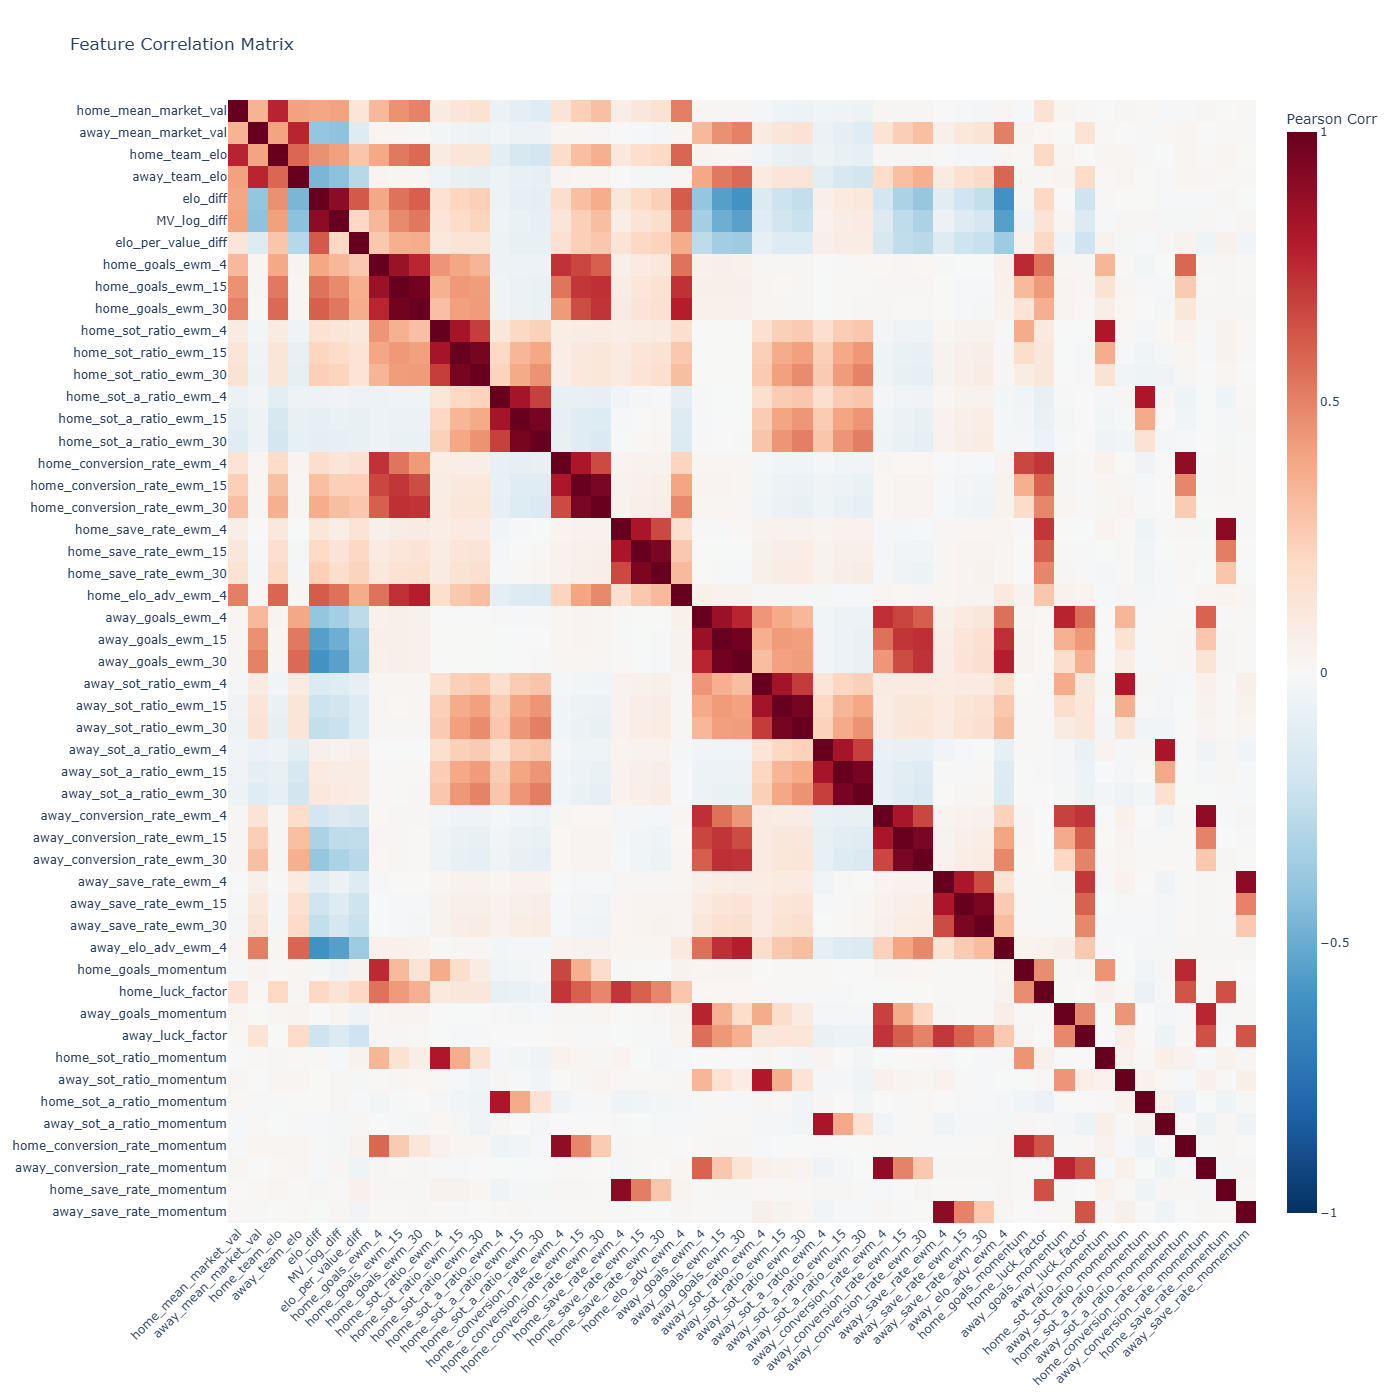

In [19]:
from pipeline.plotter import plot_corr_matrix
plot_corr_matrix(ml_features.drop("match_id"), size=(1400, 1400))

From the correlation matrix we can spot a number very high correlations:
- All the EWM_30 features are heavily correlated with EWM_15. Also EWM_15 is quite correlated with EWM_4. This suggest a team's average doesn't change much over a window of 15 games compared to 30 games meaning we can safely drop all EWM_15 features.
- All EWM_4 are heavily correlated with the momentum features. Since the momentum features directly measure the spread of average form and recent form we'll keep those and drop the EWM_4 features
- Interestingly elo difference is heavily correlated with market val log difference, but elo per value difference is not. This means we can just have elo difference and elo per market val difference as to cover both market value and elo.
- Finally luck factor is too similar to the EWM_30 conversion rate and EWM_30 save rate which makes sense since it's a simple addition so we omit it too.

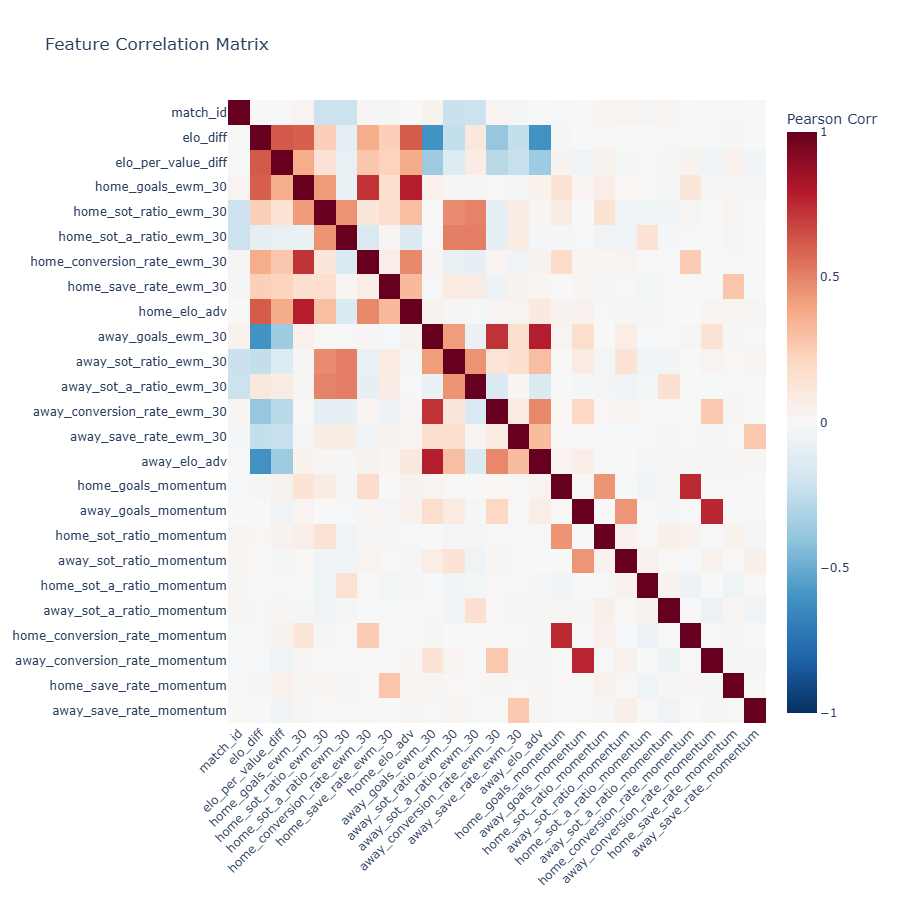

In [20]:
# Renaming Elo Advantage so it doesn't get dropped with all the EWM_4 features
ml_features = (
    ml_features
    .rename({
        f"home_elo_adv_ewm_{SHORT_WINDOW}": "home_elo_adv",
        f"away_elo_adv_ewm_{SHORT_WINDOW}": "away_elo_adv"
    })
)

ml_features = ml_features.drop([
    feature 
    for feature in ml_features.columns 
    if (f"ewm_{MEDIUM_WINDOW}" in feature) or (f"ewm_{SHORT_WINDOW}" in feature)
])

for side in ("home", "away"):
    ml_features = ml_features.drop(
        f"{side}_luck_factor", 
        f"{side}_mean_market_val",
        f"{side}_team_elo"
    )

ml_features = ml_features.drop("MV_log_diff")
plot_corr_matrix(ml_features, size=(900, 900))

Now the correlation is looking much better and we've greatly reduced our feature set.

#### Variance Inflation Factor

We now move on to our other unsupervised test: **Variance Inflation Factor (VIF)**  
The way VIF works is it runs a linear regression on each feature as the target and all the other features as inputs to the regression model. This lets it detect if a feature can be made using a linear combination of the other features. For each feature it gives a score from 0 to infinity. The smaller the value the more unpredictable the feature was. Using research we found an acceptable value was less than 5.

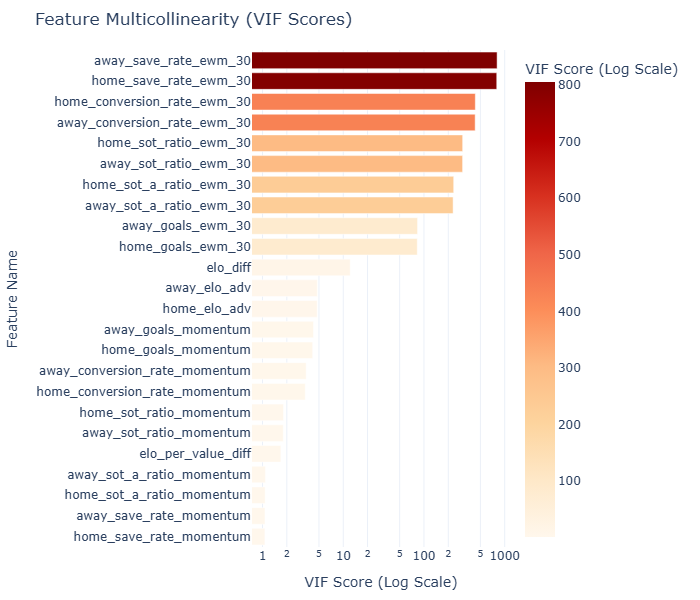

In [21]:
from pipeline.feature_engineering import calculate_vif
from pipeline.plotter import plot_vif
vif_results = pl.DataFrame(calculate_vif(ml_features))
plot_vif(vif_results)

So it looks many of our features are way above our threshold. Most of the long moving average features seem to be very similar to each due to their insanely high VIF scores. It may also be due to the fact that home and away moving averages are probably going to be correlated too. The VIF is useful but it doesn't tell you which features we should keep. So we'll come back to this after we do supervised selection. In case we miss any important combinations we will add the differences of home and away all the rolling average features too to see if they create any signal.

In [22]:
ml_features = ml_features.with_columns(
    conversion_diff=pl.col("home_conversion_rate_ewm_30") - pl.col("away_conversion_rate_ewm_30"),
    sot_diff=pl.col("home_sot_ratio_ewm_30") - pl.col("away_sot_ratio_ewm_30"),
    sot_a_diff=pl.col("home_sot_a_ratio_ewm_30") - pl.col("away_sot_a_ratio_ewm_30"),
    save_diff=pl.col("home_save_rate_ewm_30") - pl.col("away_save_rate_ewm_30"),
    elo_adv_diff=pl.col("home_elo_adv") - pl.col("away_elo_adv"),
)

#### Supervised Feature Selection

Before we perform supervised feature selection, we should investigate how good the bookmaker's implied probabilities are at predicting football match outcomes. We will use two metrics to compare our future models with.

Log Loss:  
Defined as $$ -(y\log(p) + (1 - y)\log(p)) $$ 
Where $y$ is a binary variable with 1 if the event happens and 0 if it doesn't and $p$ is the bookmaker's or model's probability of that event happening.

Accuracy:  
The percentage of correct predictions given by the bookmaker or model by taking the outcome with the highest probability.

First we calculate the implied probabilities by inverting and normalizing.

In [23]:
from pipeline.feature_engineering import calculate_market_probs

probs = training_df.select(
    "match_id", "Datetime", "Season", "FTR", "AvgH", "AvgA", "AvgD"
)
probs = calculate_market_probs(probs).drop("AvgH", "AvgA", "AvgD")
probs

match_id,Datetime,Season,FTR,home_prob,away_prob,draw_prob
u32,datetime[μs],str,str,f64,f64,f64
2846,2020-07-01 17:15:00,"""2020/2021""","""H""",0.572969,0.178846,0.248185
2847,2020-07-01 18:00:00,"""2020/2021""","""H""",0.66392,0.132233,0.203847
2848,2020-07-01 18:00:00,"""2020/2021""","""A""",0.398858,0.298212,0.30293
2849,2020-07-01 18:00:00,"""2020/2021""","""H""",0.377323,0.330483,0.292195
2850,2020-07-01 18:30:00,"""2020/2021""","""A""",0.407546,0.275624,0.31683
…,…,…,…,…,…,…
23203,2026-03-09 17:00:00,"""2025/2026""","""D""",0.500502,0.232467,0.267032
23204,2026-03-09 17:00:00,"""2025/2026""","""A""",0.264907,0.472463,0.26263
23205,2026-03-09 19:45:00,"""2025/2026""","""H""",0.432746,0.273313,0.293941


When training and validating we use a time series split that let's us have a large train and validation set. It works by splitting the data into sections (5 for example), trains the model on the first section then validates the second section. Then trains the model on the first and second section then validates on the third section. And so on until it trains on every section except the last one and validates that one. To have an accurate comparison we'll run the bookmaker's implied probabilities through the same validation sets.

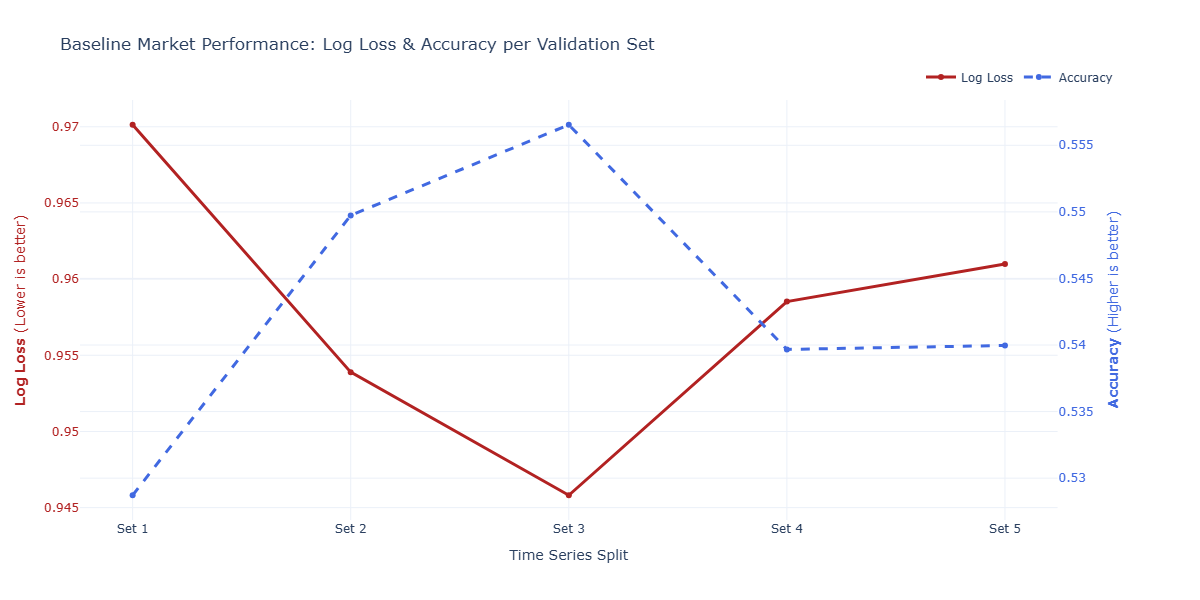

In [24]:
from sklearn.model_selection import TimeSeriesSplit
from pipeline.plotter import plot_bookmaker_baseline
from sklearn.metrics import log_loss, accuracy_score

time_split = TimeSeriesSplit(n_splits=5)
# Replace H, D, A with 2, 1, 0 for models later
mapping = {"H": 2, "D": 1, "A": 0}
y = training_df.select(
    pl.col("FTR").replace(mapping).cast(pl.Int64)
).to_numpy().ravel()

market_probs = probs.select(["away_prob", "draw_prob", "home_prob"]).to_numpy()

results = []
for i, (train_idx, test_idx) in enumerate(time_split.split(y)):
    y_test = y[test_idx]
    probs_test = market_probs[test_idx] 
    
    # 1. Calculate Log Loss
    loss = log_loss(y_test, probs_test, labels=[0, 1, 2])
    
    # 2. Calculate Accuracy
    # Market prediction is the outcome with the highest probability
    preds_test = np.argmax(probs_test, axis=1) # type: ignore
    acc = accuracy_score(y_test, preds_test)
    
    results.append({
        "Validation Set": f"Set {i+1}",
        "Log Loss": loss,
        "Accuracy": acc
    })

# Create a Polars DataFrame from the results
metrics_df = pl.DataFrame(results)
plot_bookmaker_baseline(metrics_df)


From what we can see the bookmaker's accuracy hovers around 55% for our training data. This is much better than random which would be likely be much faster 33% win rate. 

#### ANOVA Test

Now that we have a baseline from the Bookmaker’s implied probabilities, we want to test how good each of our features are at individually predicting the football match outcomes. 
To do this, we use analysis of variance (ANOVA) - a statistical test that checks whether variation between groups are random or due to real differences. The F-scores are the test statistic that indicate how well each of our features separate match outcomes (home, draw, and away) and is calculated from the formula: between-group variance / within-group variance. We can then determine whether these scores are statistically significant from the p-values using a 5% significance level.
We have chosen to first test the correlation of the Bookmaker’s implied probabilities with the match outcomes. As probabilities are compressed between 0 and 1, significance between values can be lost. To account for this, we calculate market logits (logit(p)=log(1−p/p)) to transform the range to between -∞ and +∞. The same ANOVA test is then carried out on each of our individual features.

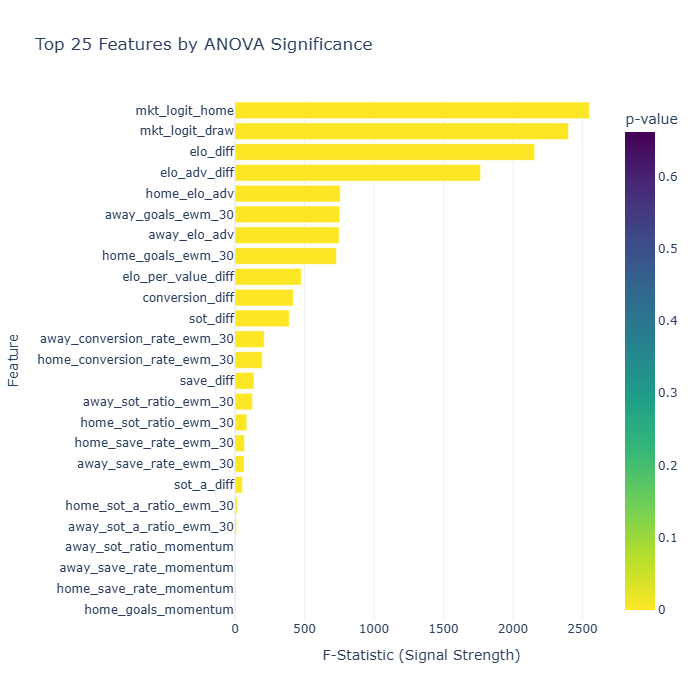

In [25]:
from pipeline.plotter import plot_anova_importance
from scipy.stats import f_oneway

log_probs = probs.with_columns(
    mkt_logit_home=(pl.col("home_prob") / pl.col("away_prob")).log(),
    mkt_logit_draw=(pl.col("draw_prob") / pl.col("away_prob")).log()
).drop(cs.matches(r"_prob$") | cs.matches("^FTR"))

all_features = ml_features.join(
    log_probs,
    on=["match_id", "Datetime", "Season"],
    how="left"
).drop("match_id", "Datetime", "Season")

features = all_features.columns
full_df = all_features.with_columns(pl.Series("outcome", y))
anova_results = []

for col in features:
    groups = [
        full_df.filter(pl.col("outcome") == label).get_column(col).to_numpy()
        for label in [0, 1, 2]
    ]
    
    f_stat, p_val = f_oneway(*groups)
    anova_results.append({
        "Feature": col,
        "F-Statistic": f_stat,
        "p-value": p_val
    })

anova_df = pl.DataFrame(anova_results).sort("F-Statistic", descending=True)
plot_anova_importance(anova_df, top_n=25)

As we can see the bookmaker's logits have the biggest effect on the outcome's variance. This strong correlation motivates the use of the Bookmaker’s market logits as a feature to train our model on. Combined with our high performing custom features, this allows us to build on top of the knowledge already incorporated by the Bookmaker’s odds with extra information not factored in - maximising our edge over the Bookmaker.

### Model Selection and Recursive Feature Selection

Before we can directly test our features, we need to choose the models we want to train.
The 3 models we have decided on are:  

**Multinomial Logistic Regression**  
Multinomial Logistic Regression is a linear implemented logistic regression for more than 2 classes. Scores are calculated using a model for each class, with higher scores converting to a higher probability for that outcome. Therefore, it assumes each feature pushes most towards an outcome independently of the other classes (no ordering). While this is a simple model that works well, it will not capture more complex, non-linear patterns.

**Extreme Gradient Boosting (XGBoost)**  
XGBoost is a machine learning model that combines several small decision trees to adjust for each other’s mistakes by calculating the residuals and splitting level-wise. XGBoost provides efficient learning and allows non-linear relationships between features to be captured without the need for too much tuning of parameters.

**Light Gradient Boost Machine (LightGBM)**  
LightGBM is another gradient boosting model that uses smaller decision trees to fix each other’s errors. The split occurs leaf-wise at the leaf with the latest residual. This technique uses fewer splits and provides faster learning over larger amounts of data while still capturing non-linear patterns. However, this increases risk of overfitting and detecting fake patterns from noisy data if parameters are not tuned properly.

In [27]:
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from pipeline.feature_engineering import get_model_eval, forward_selection

start_feats = ["mkt_logit_home", "mkt_logit_draw"]
candidates = [c for c in all_features.columns if c not in start_feats]

model_results = {}

name = "Logistic"
model = LogisticRegression(max_iter=1000)

print(f"\n--- Running Selection for {name} ---")
final_feats = forward_selection(model, start_feats, candidates, all_features, y, time_split)
_, _, split_losses, split_accuracies = get_model_eval(
    model, all_features.select(final_feats).to_numpy(), y, time_split
)
model_results[name] = {
    "losses": split_losses, "accuracies": split_accuracies, "features": final_feats
}


--- Running Selection for Logistic ---
Added feature away_conversion_rate_ewm_30
Added feature elo_diff
Added feature away_sot_ratio_momentum
Added feature elo_adv_diff
Added feature home_save_rate_momentum


In [28]:
name = "XGBoost"
model = XGBClassifier(
        n_estimators=100, 
        learning_rate=0.05, 
        objective='multi:softprob', 
        num_class=3,
        eval_metric='mlogloss',
        random_state=42
    )

print(f"\n--- Running Selection for {name} ---")
final_feats = forward_selection(model, start_feats, candidates, all_features, y, time_split)
# Final pass to get split-by-split data for plotting
_, _, split_losses, split_accuracies = get_model_eval(
    model, all_features.select(final_feats).to_numpy(), y, time_split
)
model_results[name] = {
    "losses": split_losses, "accuracies": split_accuracies, "features": final_feats
}


--- Running Selection for XGBoost ---
Added feature home_sot_ratio_ewm_30


In [29]:
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

name = "LightGBM"
model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, verbosity=-1)

print(f"\n--- Running Selection for {name} ---")
final_feats = forward_selection(model, start_feats, candidates, all_features, y, time_split)
# Final pass to get split-by-split data for plotting
_, _, split_losses, split_accuracies = get_model_eval(
    model, all_features.select(final_feats).to_numpy(), y, time_split
)
model_results[name] = {
    "losses": split_losses, "accuracies": split_accuracies, "features": final_feats
}


--- Running Selection for LightGBM ---
Added feature home_sot_ratio_ewm_30
Added feature away_sot_ratio_momentum
Added feature conversion_diff
Added feature elo_diff
Added feature home_sot_a_ratio_momentum
Added feature away_goals_ewm_30
Added feature home_elo_adv
Added feature home_save_rate_ewm_30


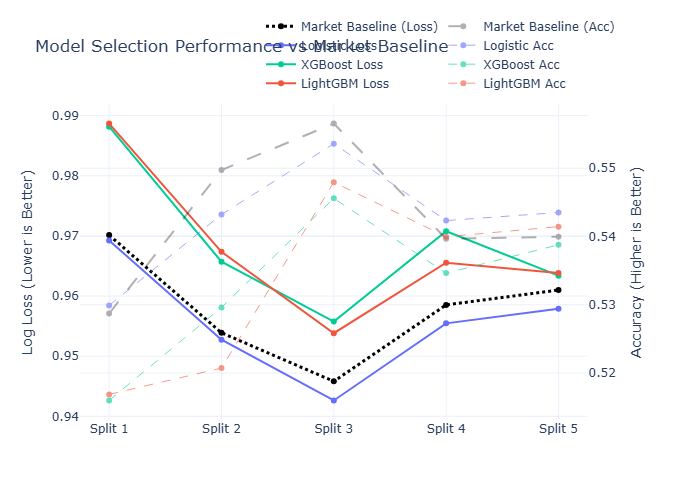

In [30]:
from pipeline.plotter import plot_model_comparison
market_results = results
plot_model_comparison(market_results, model_results)

The graph above shows that all our models except for logistic regression were outperformed by the market baseline in both log loss minimization and accuracy. The log loss from our logistic regression model is lower than the baseline at all points during the validation process. However, its accuracy only starts to overtake the market baseline after split 3, indicating growth in its performance as it gets trained on more data. It is definitely clear that we should reject all of our non-linear models.

#### Logistic Regression with P Values

Now that we have decided on our model, we want to finalise which features to use. Since we are using a linear model, this allows us to run a statistical linear logistic regression with p-values on the coefficients used in the equation for each outcome. Since the third set of probabilities can be calculated using those from the first 2 outcomes, we run this test for target y = 1 (draw) and y = 2 (home win). We reject the features that have a confidence interval that includes 0.
We chose which features to test based on those that were chosen for our logistic regression model during recursive selection. To encompass both home and away information, away conversion rate is replaced with conversion difference. Since elo per value difference has a high correlation with elo difference, we want to test which performs better when incorporated into our final model. So the features we are testing are:
- Conversion Difference
- Elo Difference
- Elo per Value Difference
- Away Shots on Target Momentum
- Elo Advantage
- Home Save Rate Momentum

In [31]:
import polars as pl
import numpy as np
from pipeline.feature_engineering import run_stats_investigation

market_features = ["mkt_logit_home", "mkt_logit_draw"]
features = market_features + [
    "elo_diff", "away_sot_ratio_momentum", "elo_adv_diff", 
    "home_save_rate_momentum", "conversion_diff", "elo_per_value_diff"
]
run_stats_investigation(all_features, y, features)

                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                20270
Model:                        MNLogit   Df Residuals:                    20252
Method:                           MLE   Df Model:                           16
Date:                Fri, 20 Mar 2026   Pseudo R-squ.:                  0.1074
Time:                        17:51:53   Log-Likelihood:                -19441.
converged:                       True   LL-Null:                       -21779.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    y=1       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -0.0502      0.021     -2.390      0.017      -0.091      -0.009
mkt_logit_home              0.0547      0.111      0.492      0.622      -0.163       0.272


Both elo advantage and home save rate momentum are rejected using our statistical test. However, we are also choosing to drop away shots on target momentum based on its low coefficient and the fact that there was no significant correlation between its home counterpart and the outcome. Additionally, all other momentum features have zero correlation with the outcome, suggesting this significance is likely noise and its low coefficient indicates our model will not be impacted very strongly if it is removed. This narrows down our features to conversion difference, elo difference, and elo per value difference.

#### Elo Difference and Conversion Difference Logistic Regression P Value Tests

In [32]:
features = market_features + [
    "elo_diff", "conversion_diff"
]
run_stats_investigation(all_features, y, features)

                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                20270
Model:                        MNLogit   Df Residuals:                    20260
Method:                           MLE   Df Model:                            8
Date:                Fri, 20 Mar 2026   Pseudo R-squ.:                  0.1068
Time:                        17:51:53   Log-Likelihood:                -19452.
converged:                       True   LL-Null:                       -21779.
Covariance Type:            nonrobust   LLR p-value:                     0.000
            y=1       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0494      0.021     -2.354      0.019      -0.091      -0.008
mkt_logit_home      0.0691      0.110      0.629      0.529      -0.146       0.284
mkt_logit_draw      0.6043      

In [33]:
features = market_features + [
    "elo_per_value_diff", "conversion_diff"
]
run_stats_investigation(all_features, y, features)

                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                20270
Model:                        MNLogit   Df Residuals:                    20260
Method:                           MLE   Df Model:                            8
Date:                Fri, 20 Mar 2026   Pseudo R-squ.:                  0.1070
Time:                        17:51:54   Log-Likelihood:                -19449.
converged:                       True   LL-Null:                       -21779.
Covariance Type:            nonrobust   LLR p-value:                     0.000
               y=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.0492      0.021     -2.344      0.019      -0.090      -0.008
mkt_logit_home         0.0448      0.094      0.478      0.632      -0.139       0.229
mkt_logit_draw      

Due to the strong correlation between elo difference and elo per value difference, we want to test each of them individually with conversion difference. It becomes clear that elo difference shows greater statistical significance and would drive a greater edge in our model’s probabilities as its coefficient is almost double that of elo per value difference. Therefore, we finalize our features down to just: 
- Conversion Rate 
- Elo Difference

One idea why this has effect is bookmaker overconfidence. We notice both features have a negative coefficient for y=2 which is the home win outcome. This means as both the conversion rate difference and elo difference between the home and away team increases we lower the probability of a home win. This suggests bookmaker's are slightly overweighing the impact of a team high scoring form and their elo difference.

In [34]:
chosen_features = ["elo_diff", "conversion_diff"]
final_features = ml_features.select("match_id", "Datetime", "Season", *chosen_features)
final_features = final_features.join(
    log_probs,
    on=["match_id", "Datetime", "Season"],
    how="left"
)
final_features

match_id,Datetime,Season,elo_diff,conversion_diff,mkt_logit_home,mkt_logit_draw
u32,datetime[μs],str,f64,f64,f64,f64
2846,2020-07-01 17:15:00,"""2020/2021""",69.591797,-0.01155,1.164308,0.327648
2847,2020-07-01 18:00:00,"""2020/2021""",213.369629,0.082905,1.613596,0.432806
2848,2020-07-01 18:00:00,"""2020/2021""",-76.773193,0.004454,0.290802,0.015699
2849,2020-07-01 18:00:00,"""2020/2021""",-47.651611,-0.023135,0.132547,-0.123133
2850,2020-07-01 18:30:00,"""2020/2021""",-14.499268,0.005828,0.391118,0.139329
…,…,…,…,…,…,…
23203,2026-03-09 17:00:00,"""2025/2026""",61.326904,-0.006557,0.766865,0.13862
23204,2026-03-09 17:00:00,"""2025/2026""",-187.862549,-0.06395,-0.578581,-0.587214
23205,2026-03-09 19:45:00,"""2025/2026""",49.79126,-0.03578,0.459532,0.072759


### Training and Testing

Now that we've confirmed our features and the model we're going to use we will train on 4 seasons of data from the 2020/2021 season to 2023/2024 season and test on the 2024/2025 season and 2025/2026 season.

In [35]:
from pipeline.models.multimodal import MultiModalLogitWrapper

final_model = MultiModalLogitWrapper(lasso=False)

TRAIN_SEASONS = [20, 21, 22, 23]
TEST_SEASONS = [24, 25]
train_seasons = [f"20{season}/20{season + 1}" for season in TRAIN_SEASONS]
test_seasons = [f"20{season}/20{season + 1}" for season in TEST_SEASONS]

features = chosen_features + market_features
target_col = 'FTR'

X_train = final_features.filter(pl.col("Season").is_in(train_seasons))
y_train = training_df.filter(pl.col("Season").is_in(train_seasons)).select("match_id", "Datetime", "Season", 'FTR')

X_test = final_features.filter(pl.col("Season").is_in(test_seasons))
y_test = training_df.filter(pl.col("Season").is_in(test_seasons)).select("match_id", "Datetime", "Season", 'FTR')

final_model.fit(X_train, y_train)

To test against a baseline we'll use our exact trading strategy using the implied probabilities from the average odds for each bookmaker.

In [36]:
# Your current model prediction logic
preds = final_model.predict(X_test)
model_probs = pl.DataFrame(preds, schema=["m_away_probs", "m_draw_probs", "m_home_probs"])
market_probs = (
    probs.filter(pl.col("Season").is_in(test_seasons))
    .select([
        pl.col("away_prob").alias("m_away_probs"),
        pl.col("draw_prob").alias("m_draw_probs"),
        pl.col("home_prob").alias("m_home_probs"),
        pl.col("match_id")
    ])
)

# Ensure match_id is present if it wasn't added in the 'else' block
if "match_id" not in model_probs.columns:
    model_probs = model_probs.with_columns(
        match_id = training_df.filter(
            pl.col("Season").is_in(test_seasons)
        ).get_column("match_id")
    )

model_probs

m_away_probs,m_draw_probs,m_home_probs,match_id
f64,f64,f64,u32
0.102871,0.189193,0.707935,17297
0.387762,0.286867,0.325371,17299
0.139646,0.217359,0.642995,17300
0.115482,0.199857,0.684662,17301
0.603605,0.220469,0.175926,17302
…,…,…,…
0.2134,0.277926,0.508675,23203
0.469358,0.270125,0.260517,23204
0.253541,0.314866,0.431593,23205


## Signal Generation

Now that we have our model's probabilities of the outcome of each model all we need is a signal that tells us which outcome to bet on. We do this by calculating the expected value of each bet using our model's probability and the max odds out of the available bookmakers for that outcome. We use the max odds since that's we would be searching for if we were betting properly online to maximize our winning. For each match only bet if one outcome has a positive expected value we choose the outcome with the highest expected value. We then filter these bets into a bet series below.

In [37]:
from pipeline.risk import create_bet_series, create_ev_series

outcomes = y_test

model_ev_series = create_ev_series(model_probs, outcomes, test_seasons, training_df)
market_ev_series = create_ev_series(market_probs, outcomes, test_seasons, training_df)

model_bet_series = create_bet_series(model_ev_series)
market_bet_series = create_bet_series(market_ev_series)
# Outlier
model_bet_series = model_bet_series.filter(pl.col("match_id") != 22149)
market_bet_series = market_bet_series.filter(pl.col("match_id") != 22149)

model_bet_series

match_id,Datetime,Season,outcome,odds,model_probability
u32,datetime[μs],str,str,f64,f64
17297,2024-07-26 19:45:00,"""2024/2025""","""loss""",1.42,0.707935
17299,2024-07-27 17:15:00,"""2024/2025""","""win""",3.56,0.286867
17301,2024-07-28 12:30:00,"""2024/2025""","""loss""",1.52,0.684662
17302,2024-07-28 15:00:00,"""2024/2025""","""win""",1.66,0.603605
17303,2024-07-28 17:30:00,"""2024/2025""","""win""",2.29,0.447268
…,…,…,…,…,…
23201,2026-03-09 13:00:00,"""2025/2026""","""loss""",3.25,0.313728
23202,2026-03-09 16:00:00,"""2025/2026""","""loss""",3.25,0.317799
23205,2026-03-09 19:45:00,"""2025/2026""","""loss""",3.3,0.314866


## Money Management

We implement three different money management techniques:
- flat bet: Bet the same amount every time
- fixed fraction: Bet the same fraction every time
- kelly criterion: Bet the optimal fraction based on the expected value

For kelly criterion we also implement less aggressive versions by scaling the given kelly fraction by another fraction. This is called fractional kelly and it helps because kelly criterion by itself only works if you know exactly what the probabilities are. If the model is a little inaccurate it's kelly will be ver volatile and likely lose money. This is why we only look at fractional kelly up to 0.5.

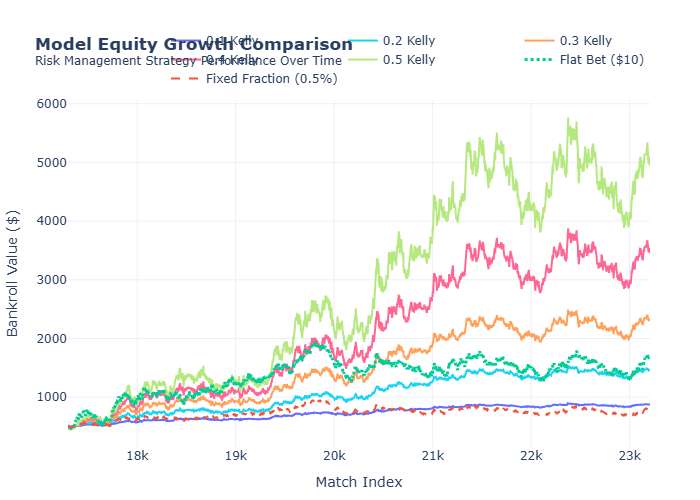

In [38]:
from pipeline.plotter import plot_equity_comparison
# Configuration
INITIAL_BANK = 500
FLAT_BET_SIZE = 10     # For Flat Bet
FIXED_FRACTION = 0.005   # For Fixed Percentage (2%)
KELLY_FRACTIONS = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

plot_equity_comparison(
    "Model", model_bet_series, INITIAL_BANK, FLAT_BET_SIZE, FIXED_FRACTION, KELLY_FRACTIONS
)

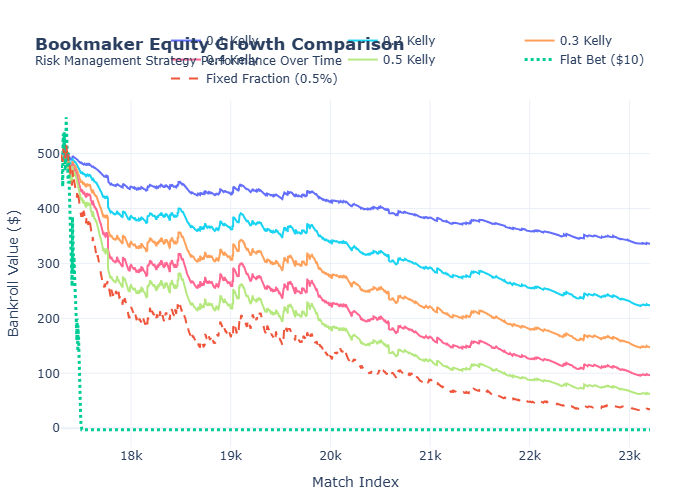

In [39]:
from pipeline.plotter import plot_equity_comparison
# Configuration
INITIAL_BANK = 500
FLAT_BET_SIZE = 10     # For Flat Bet
FIXED_FRACTION = 0.005   # For Fixed Percentage (2%)
KELLY_FRACTIONS = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

plot_equity_comparison(
    "Bookmaker", market_bet_series, INITIAL_BANK, FLAT_BET_SIZE, FIXED_FRACTION, KELLY_FRACTIONS
)

As we can see our model does make a significant amount of money when used with fractional kelly. Through some further testing we found that to satisfy our chosen threshold of max drawdown of 30% fractional kelly with 0.4 works the best. Note that the baseline where we used the bookmaker's implied probabilities calculated from the avg odds and bet on the max odds it actually loses money. This invalidates one counter-hypothesis that out model is just copying the bookmaker's implied probabilities and not providing any edge.

## Evaluation

In [40]:
from pipeline.risk import kelly_criterion
from pipeline.evaluation import evaluate_returns, get_evaluation_table, apply_clean_theme
from pipeline.metrics.performance import (
    median_PNL, mean_PNL, total_PNL, number_of_bets, win_rate, loss_rate, compound_return
)
from pipeline.metrics.risk_adjusted import sharpe_ratio, calmer_ratio, sortino_ratio
from pipeline.metrics.drawdown import (
    max_drawdown, max_time_underwater, average_drawdown, avg_time_underwater
)
from pipeline.metrics.volatility import volatility, downside_volatility, skewness, kurtosis, best_bet, worst_bet

KELLY_FRACTION = 0.4

metrics = {
    "Performance": [mean_PNL, median_PNL, total_PNL, number_of_bets, win_rate, loss_rate, compound_return],
    "Distribution": [volatility, downside_volatility, skewness, kurtosis, best_bet, worst_bet],
    "Risk Adjusted Returns": [sharpe_ratio, calmer_ratio, sortino_ratio],
    "Drawdown": [max_drawdown, max_time_underwater, average_drawdown, avg_time_underwater]
}

equity_series = kelly_criterion(model_bet_series, INITIAL_BANK, KELLY_FRACTION)
equity_series = equity_series.rename({"prev_bank_roll": "prev_bankroll", "new_bank_roll": "new_bankroll"})
returns = evaluate_returns(equity_series, metrics)
apply_clean_theme(get_evaluation_table(returns, title="Results", subtitle=""))

GT(_tbl_data=shape: (20, 6)
┌───────────────────────┬─────────────────────────────────┬─────────────┬──────────┬─────┬───────┐
│ Type                  ┆ Metric                          ┆ Value       ┆ fmt      ┆ dec ┆ sign  │
│ ---                   ┆ ---                             ┆ ---         ┆ ---      ┆ --- ┆ ---   │
│ str                   ┆ str                             ┆ f64         ┆ str      ┆ i64 ┆ bool  │
╞═══════════════════════╪═════════════════════════════════╪═════════════╪══════════╪═════╪═══════╡
│ Performance           ┆ Mean Pnl (Per Bet)              ┆ 0.605169    ┆ currency ┆ 2   ┆ true  │
│ Performance           ┆ Median Pnl (Per Bet)            ┆ -2.57134    ┆ currency ┆ 2   ┆ true  │
│ Performance           ┆ Total Pnl                       ┆ 3001.640334 ┆ currency ┆ 2   ┆ true  │
│ Performance           ┆ Number Of Bets                  ┆ 4960.0      ┆ number   ┆ 0   ┆ false │
│ Performance           ┆ Win Rate                        ┆ 0.425605    ┆ percent  ┆ 1   ┆ false │
│ …                     ┆ …                               ┆ …           ┆ …        ┆ …   ┆ …     │
│ Risk Adjusted Returns ┆ Sortino Ratio (Season-Adjusted… ┆ 2.24579     ┆ number   ┆ 3   ┆ false │
│ Drawdown              ┆ Max Drawdown                    ┆ 0.281356    ┆ percent  ┆ 1   ┆ false │
│ Drawdown              ┆ Max Time Underwater (Bets)      ┆ 618.0       ┆ number   ┆ 0   ┆ false │
│ Drawdown              ┆ Average Drawdown                ┆ 0.096665    ┆ percent  ┆ 1   ┆ false │
│ Drawdown              ┆ Avg Time Underwater (Bets)      ┆ 45.037736   ┆ number   ┆ 1   ┆ false │
└───────────────────────┴─────────────────────────────────┴─────────────┴──────────┴─────┴───────┘, _body=<great_tables._gt_data.Body object at 0x0000014220734AD0>, _boxhead=Boxhead([ColInfo(var='Type', type=<ColInfoTypeEnum.row_group: 3>, column_label='Type', column_align='left', column_width=None), ColInfo(var='Metric', type=<ColInfoTypeEnum.stub: 2>, column_label='Metric', column_align='left', column_width=None), ColInfo(var='Value', type=<ColInfoTypeEnum.default: 1>, column_label='Value', column_align='right', column_width=None), ColInfo(var='fmt', type=<ColInfoTypeEnum.hidden: 4>, column_label='fmt', column_align='left', column_width=None), ColInfo(var='dec', type=<ColInfoTypeEnum.hidden: 4>, column_label='dec', column_align='right', column_width=None), ColInfo(var='sign', type=<ColInfoTypeEnum.hidden: 4>, column_label='sign', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000014220734590>, _spanners=Spanners([]), _heading=Heading(title='Results', subtitle='', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000014220734D70>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000001420C651090>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Value', rownum=None, colnum=None, styles=[CellStyleFill(color='#2c3e50')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='fmt', rownum=None, colnum=None, styles=[CellStyleFill(color='#2c3e50')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='dec', rownum=None, colnum=None, styles=[CellStyleFill(color='#2c3e50')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='sign', rownum=None, colnum=None, styles=[CellStyleFill(color='#2c3e50')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Value', rownum=None, colnum=None, styles=[CellStyleText(color='white', font=None, size='12px', align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform='uppercase', whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='fmt', rownum=None, colnum=None, styles=[CellStyleText(color='white', font=None, size='12px', align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=No

Looking at our metrics we can we're pretty happy with the results:
- Even though our median pnl is negative our mean pnl is positive suggesting we win less then we loss but when we win we earn more to make up for our losses
- We have about 5,000 bets for only 2 seasons suggesting we way past the point where we would just be lucky to see this consistent returns
- Our Calmer ratio is very high since it suggest per season we earn about 4 times our maximum drawdown. This means we can be pretty confident each season we'll make money. Our Sortino is much high than our sharpe suggesting we less downside volatility than upside
- Max Drawdown is only 28% meaning in the whole 2 seasons we never lose more than 28% of our bankroll. Additionally we're only underwater on average 45 bets which only amounts to maybe a month of betting.

Overall we believe in we've found a significant edge by using the bookmaker's own probabilities to incorporate market information then adjusting the probabilities based on the club elo difference and the conversion rate of each team to get a more accurate.